In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df=pd.read_csv("water.consumption.zip")

In [ ]:
df.head()

,Household_ID,Bathroom_Liters,Kitchen_Liters,Laundry_Liters,Gardening_Liters,Total_Liters,Day,Month,Year
0,7,248,162,110,100,620,0,1,2025
1,20,321,111,241,7,680,1,1,2025
2,15,253,101,67,52,473,2,1,2025
3,11,363,61,86,59,569,3,1,2025
4,8,368,88,86,107,649,4,1,2025


In [ ]:
df.tail()

,Household_ID,Bathroom_Liters,Kitchen_Liters,Laundry_Liters,Gardening_Liters,Total_Liters,Day,Month,Year
95,12,208,164,239,129,740,5,4,2025
96,2,267,168,229,34,698,6,4,2025
97,1,309,71,129,80,589,7,4,2025
98,16,245,87,74,89,495,8,4,2025
99,5,365,158,113,7,643,9,4,2025


In [ ]:
df.shape

(100, 7)

In [ ]:
df.columns

Index(['Household_ID', 'Bathroom_Liters', 'Kitchen_Liters', 'Laundry_Liters',
       'Gardening_Liters', 'Total_Liters', 'Day', 'Month', 'Year'],
      dtype='object')

In [ ]:
df.info

<bound method DataFrame.info of           Date  Household_ID  Bathroom_Liters  Kitchen_Liters  Laundry_Liters  \
0   2025-01-01             7              248             162             110   
1   2025-01-02            20              321             111             241   
2   2025-01-03            15              253             101              67   
3   2025-01-04            11              363              61              86   
4   2025-01-05             8              368              88              86   
..         ...           ...              ...             ...             ...   
95  2025-04-06            12              208             164             239   
96  2025-04-07             2              267             168             229   
97  2025-04-08             1              309              71             129   
98  2025-04-09            16              245              87              74   
99  2025-04-10             5              365             158             113   

    Gardening_Liters  Total_Liters  
0                100           620  
1                  7           680  
2                 52           473  
3                 59           569  
4                107           649  
..               ...           ...  
95               129           740  
96                34           698  
97                80           589  
98                89           495  
99                 7           643  

[100 rows x 7 columns]>

In [ ]:
df.describe()

,Household_ID,Bathroom_Liters,Kitchen_Liters,Laundry_Liters,Gardening_Liters,Total_Liters,Day,Month,Year
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
mean,10.010000,285.950000,141.530000,149.240000,74.660000,651.380000,13.530000,2.200000,2025.0
std,5.535003,74.076179,43.387485,56.358542,44.386553,108.978339,8.887007,0.994937,0.0
min,1.000000,150.000000,51.000000,63.000000,0.000000,436.000000,0.000000,1.000000,2025.0
25%,5.750000,223.000000,103.000000,101.000000,33.750000,570.750000,6.000000,1.000000,2025.0
50%,9.500000,286.000000,151.500000,145.000000,79.500000,657.500000,13.000000,2.000000,2025.0
75%,15.000000,354.250000,178.000000,202.250000,113.500000,736.250000,21.000000,3.000000,2025.0
max,20.000000,399.000000,197.000000,249.000000,146.000000,872.000000,30.000000,4.000000,2025.0


In [ ]:
df.isnull().sum()

,0
Date,0
Household_ID,0
Bathroom_Liters,0
Kitchen_Liters,0
Laundry_Liters,0
Gardening_Liters,0
Total_Liters,0


In [ ]:
print(df.columns.tolist())

['Household_ID', 'Bathroom_Liters', 'Kitchen_Liters', 'Laundry_Liters', 'Gardening_Liters', 'Total_Liters', 'Day', 'Month', 'Year']


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df = df.dropna()

In [ ]:
df.dtypes

,0
Household_ID,int64
Bathroom_Liters,int64
Kitchen_Liters,int64
Laundry_Liters,int64
Gardening_Liters,int64
Total_Liters,int64
Day,int64
Month,int32
Year,int32


In [ ]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
print(df.isnull().sum())

Household_ID        0
Bathroom_Liters     0
Kitchen_Liters      0
Laundry_Liters      0
Gardening_Liters    0
Total_Liters        0
Day                 0
Month               0
Year                0
dtype: int64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.drop("Date", axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Day"] = le.fit_transform(df["Day"])

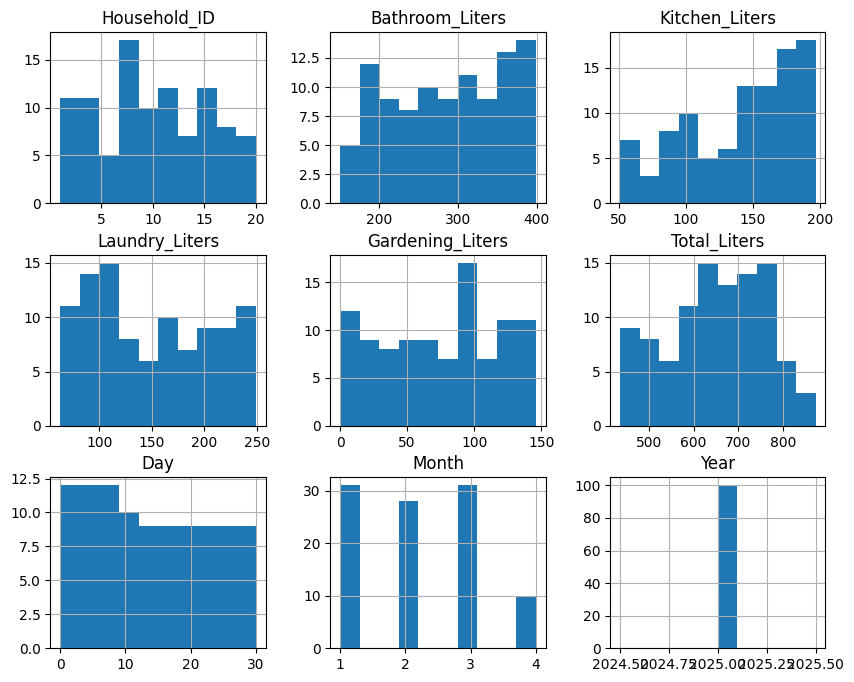

In [ ]:
df.hist(figsize=(10,8)),
plt.show()

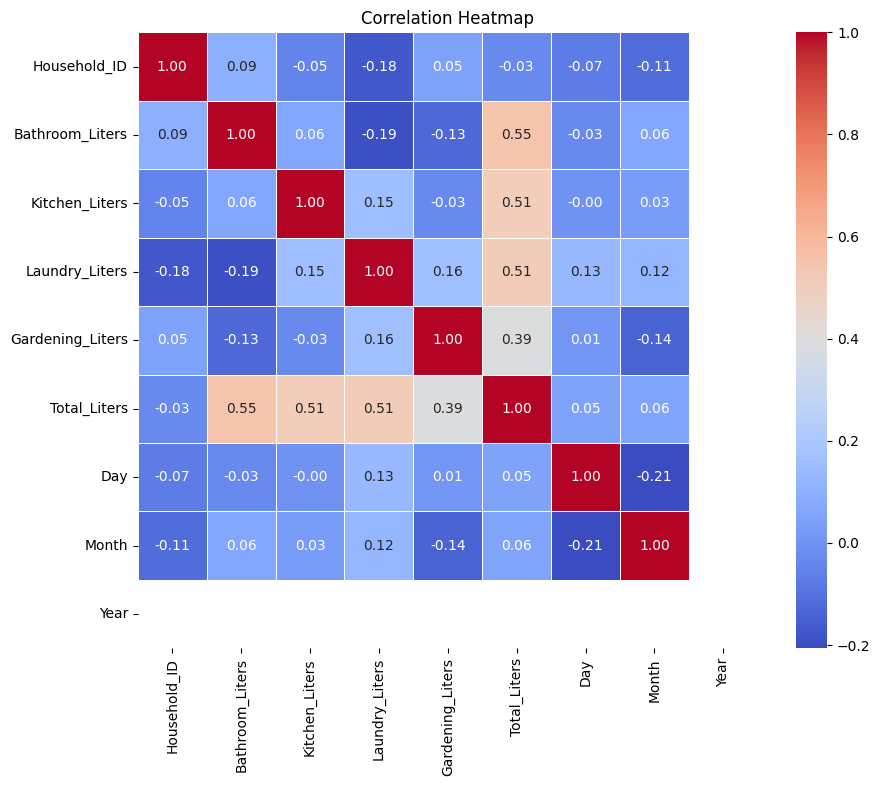

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

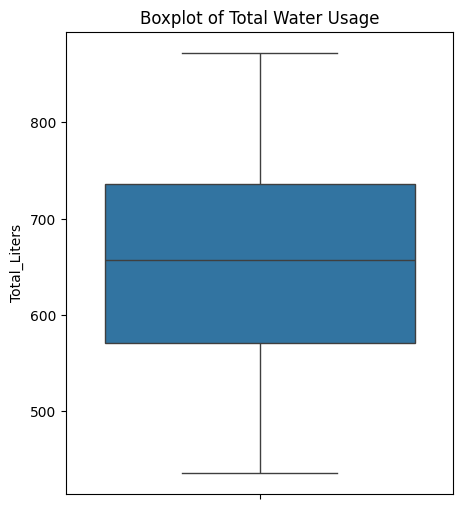

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,6))
sns.boxplot(y=df["Total_Liters"])

plt.title("Boxplot of Total Water Usage")
plt.show()

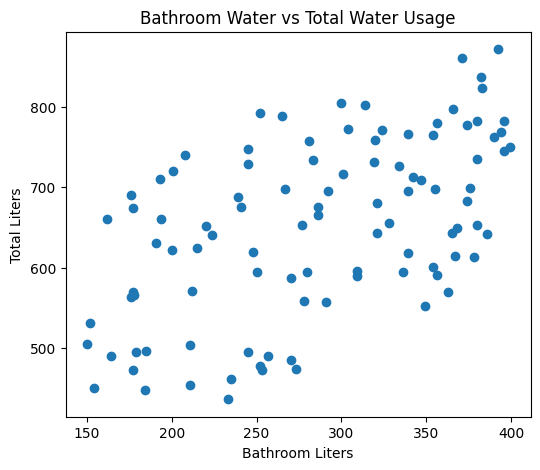

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df["Bathroom_Liters"], df["Total_Liters"])

plt.title("Bathroom Water vs Total Water Usage")
plt.xlabel("Bathroom Liters")
plt.ylabel("Total Liters")

plt.show()

In [ ]:
X = df.drop("Total_Liters", axis=1)
y = df["Total_Liters"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 9.379164112033322e-14
MSE : 1.8256134612986745e-26
RMSE: 1.3511526417465477e-13
R2 Score: 1.0


In [ ]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head(10))

    Actual  Predicted
83     709      709.0
53     454      454.0
70     735      735.0
45     652      652.0
44     596      596.0
39     696      696.0
22     688      688.0
80     837      837.0
10     698      698.0
0      620      620.0


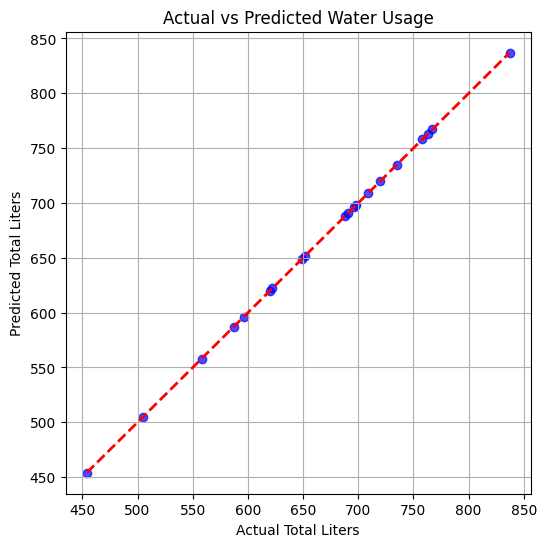

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.title("Actual vs Predicted Water Usage")
plt.xlabel("Actual Total Liters")
plt.ylabel("Predicted Total Liters")

plt.grid(True)
plt.show()

In [ ]:
coefficients=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coefficients

,Feature,Coefficient
0,Household_ID,2.008823e-15
1,Bathroom_Liters,1.000000e+00
2,Kitchen_Liters,1.000000e+00
3,Laundry_Liters,1.000000e+00
4,Gardening_Liters,1.000000e+00
5,Day,-1.351350e-15
6,Month,-3.616898e-16
7,Year,0.000000e+00


In [ ]:
sample = pd.DataFrame({
    "Household_ID": [5],
    "Bathroom_Liters": [250],
    "Kitchen_Liters": [120],
    "Laundry_Liters": [180],
    "Gardening_Liters": [90],
    "Day": [15],
    "Month": [3],
    "Year": [2025]
})

prediction = model.predict(sample)

print("Predicted Total Water Usage:", prediction[0], "Liters")

Predicted Total Water Usage: 639.9999999999999 Liters
